# 🔬 Projet 5 — Calibration d'un capteur

**Module :** Intelligence artificielle et Python  
**Filière :** PHEI | **Année Universitaire :** 2025-2026  
**PR. KHADIJA TLEMCANI** — FSAC, Université Hassan II de Casablanca

---
**Base de données :** Air Quality UCI  
**Capteur étudié :** CO — `PT08.S1(CO)` vs `CO(GT)`

## 📦 0. Importation des bibliothèques

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

print('✅ Bibliothèques importées avec succès !')

✅ Bibliothèques importées avec succès !


## 📂 1. Chargement et nettoyage des données

> ⚠️ **Important :** Place le fichier `airquality.csv` dans le **même dossier** que ce notebook.

In [3]:

df = pd.read_csv('AirQualityUCI.csv', sep=';', decimal=',')

# Aperçu des colonnes disponibles
print('Colonnes disponibles :')
print(df.columns.tolist())
print(f'\nTaille : {df.shape[0]} lignes x {df.shape[1]} colonnes')
df.head()

Colonnes disponibles :
['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'Unnamed: 15', 'Unnamed: 16']

Taille : 9471 lignes x 17 colonnes


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [6]:


# Supprimer les colonnes vides générées par le séparateur
df = df.dropna(axis=1, how='all')

# Vérification des colonnes
print("Colonnes disponibles :", df.columns.tolist())

# Les valeurs -200 = données manquantes dans ce dataset UCI
df.replace(-200, np.nan, inplace=True)

# Sélection des colonnes capteur CO et référence CO(GT)
paire = df[['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)']].dropna()
paire.columns = ['Date', 'Time', 'valeur_vraie', 'mesure_capteur']

print('=' * 58)
print('  Projet 5 – Calibration capteur (données réelles)')
print('=' * 58)
print(f'Capteur   : PT08.S1 (oxyde métallique – CO)')
print(f'Référence : CO(GT) (analyseur de référence)')
print(f'Mesures valides après nettoyage : {len(paire)}')

valeurs_vraies   = paire['valeur_vraie'].values
mesures_biaisees = paire['mesure_capteur'].values

Colonnes disponibles : ['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
  Projet 5 – Calibration capteur (données réelles)
Capteur   : PT08.S1 (oxyde métallique – CO)
Référence : CO(GT) (analyseur de référence)
Mesures valides après nettoyage : 7344


In [ ]:
## 📊 2. Statistiques des mesures

In [10]:
print('[1] Statistiques des données')
print(f'    Référence CO(GT)  — min: {valeurs_vraies.min():.2f}  max: {valeurs_vraies.max():.2f}  moy: {valeurs_vraies.mean():.2f}')
print(f'    Capteur PT08.S1   — min: {mesures_biaisees.min():.1f}  max: {mesures_biaisees.max():.1f}  moy: {mesures_biaisees.mean():.1f}')

[1] Statistiques des données
    Référence CO(GT)  — min: 0.10  max: 11.90  moy: 2.13
    Capteur PT08.S1   — min: 647.0  max: 2040.0  moy: 1110.6


## ⚠️ 3. Étude de l'erreur systématique
Normalisation entre **[0, 1]** pour comparer les deux capteurs (unités différentes).

In [9]:

# Normalisation des données (entre 0 et 1)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

mb_norm = scaler_X.fit_transform(
    mesures_biaisees.reshape(-1, 1)
).flatten()

vv_norm = scaler_y.fit_transform(
    valeurs_vraies.reshape(-1, 1)
).flatten()

print(f'mb_norm : min={mb_norm.min():.2f}, max={mb_norm.max():.2f}')
print(f'vv_norm : min={vv_norm.min():.2f}, max={vv_norm.max():.2f}')

mb_norm : min=0.00, max=1.00
vv_norm : min=0.00, max=1.00


## 🤖 4. Modèle de correction — Régression Linéaire

In [10]:
from sklearn.model_selection import train_test_split

X = mb_norm.reshape(-1, 1)
y = vv_norm

# ── Split 80% entraînement / 20% test ──────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── Entraînement sur 80% ────────────────────────────────────
modele = LinearRegression()
modele.fit(X_train, y_train)

a = modele.coef_[0]
b = modele.intercept_

# ── Prédiction sur 20% test ─────────────────────────────────
mesures_corrigees = modele.predict(X_test)

print('[3] Modèle de correction (régression linéaire)')
print(f'    valeur_corrigee = {a:.4f} × capteur + ({b:.4f})')
print(f'\n    Taille train : {len(X_train)} échantillons (80%)')
print(f'    Taille test  : {len(X_test)} échantillons (20%)')

[3] Modèle de correction (régression linéaire)
    valeur_corrigee = 0.6869 × capteur + (-0.0560)

    Taille train : 5875 échantillons (80%)
    Taille test  : 1469 échantillons (20%)


## ✅ 5. Évaluation de l'amélioration

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Évaluation sur 20% test (données inconnues) ─────────────
mae_apres  = mean_absolute_error(y_test, mesures_corrigees)
rmse_apres = np.sqrt(mean_squared_error(y_test, mesures_corrigees))
r2         = r2_score(y_test, mesures_corrigees)

# ── Baseline : erreur avant correction (sur X_test) ─────────
mae_avant  = mean_absolute_error(y_test, X_test.flatten())
rmse_avant = np.sqrt(mean_squared_error(y_test, X_test.flatten()))

amelioration_mae  = (1 - mae_apres  / mae_avant)  * 100
amelioration_rmse = (1 - rmse_apres / rmse_avant) * 100

print('[4] Évaluation de l amélioration')
print(f'    MAE  avant : {mae_avant:.4f}  ->  après : {mae_apres:.4f}  (amélioration : {amelioration_mae:.1f} %)')
print(f'    RMSE avant : {rmse_avant:.4f}  ->  après : {rmse_apres:.4f}  (amélioration : {amelioration_rmse:.1f} %)')
print(f'    R² modèle de correction : {r2:.6f}')
print('=' * 58)

[4] Évaluation de l amélioration
    MAE  avant : 0.1638  ->  après : 0.0410  (amélioration : 74.9 %)
    RMSE avant : 0.1808  ->  après : 0.0558  (amélioration : 69.2 %)
    R² modèle de correction : 0.778139


## 📈 6. Visualisations (4 graphiques)

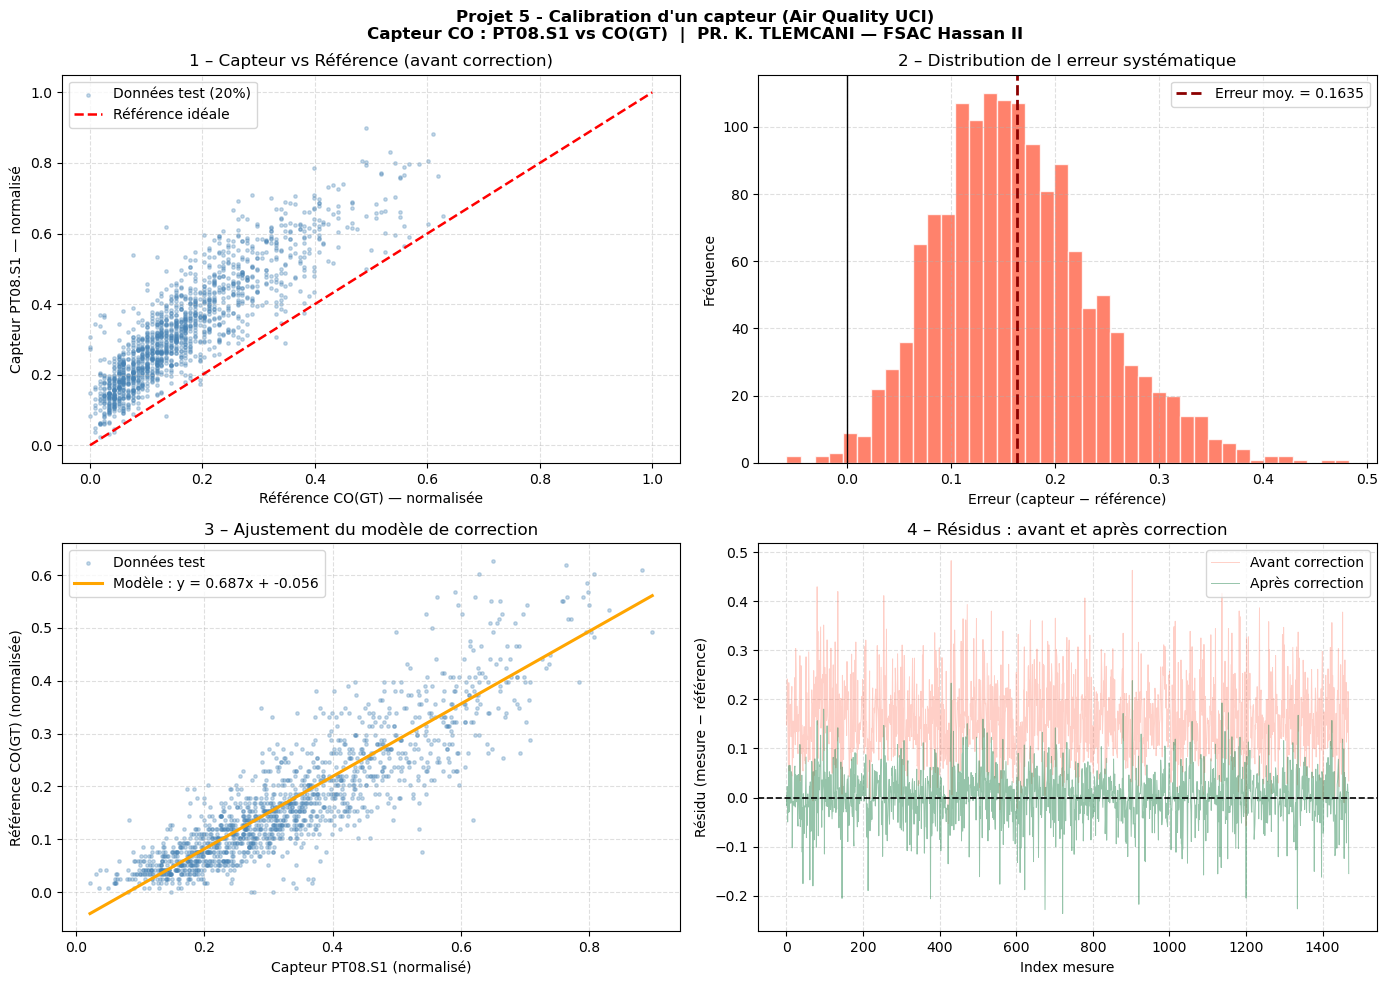


✅ Figure sauvegardée : calibration_capteur_UCI.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Projet 5 - Calibration d'un capteur (Air Quality UCI)\n"
             "Capteur CO : PT08.S1 vs CO(GT)  |  PR. K. TLEMCANI — FSAC Hassan II",
             fontsize=12, fontweight='bold')

# ── Graphique 1 : Capteur vs Référence avant correction ──
ax1 = axes[0, 0]
ax1.scatter(y_test, X_test.flatten(), s=6, alpha=0.3, color='steelblue', label='Données test (20%)')
ax1.plot([0, 1], [0, 1], 'r--', linewidth=1.8, label='Référence idéale')
ax1.set_xlabel('Référence CO(GT) — normalisée')
ax1.set_ylabel('Capteur PT08.S1 — normalisé')
ax1.set_title('1 – Capteur vs Référence (avant correction)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.4)

# ── Graphique 2 : Distribution des erreurs ──
ax2 = axes[0, 1]
erreurs       = X_test.flatten() - y_test
erreur_moyenne = erreurs.mean()
ax2.hist(erreurs, bins=40, color='tomato', edgecolor='white', alpha=0.8)
ax2.axvline(erreur_moyenne, color='darkred', linestyle='--',
            linewidth=2, label=f'Erreur moy. = {erreur_moyenne:.4f}')
ax2.axvline(0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Erreur (capteur − référence)')
ax2.set_ylabel('Fréquence')
ax2.set_title('2 – Distribution de l erreur systématique')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)

# ── Graphique 3 : Modèle de correction ──
ax3 = axes[1, 0]
x_line = np.linspace(X_test.min(), X_test.max(), 300)
y_line = a * x_line + b
ax3.scatter(X_test.flatten(), y_test, s=6, alpha=0.3, color='steelblue', label='Données test')
ax3.plot(x_line, y_line, 'orange', linewidth=2.2,
         label=f'Modèle : y = {a:.3f}x + {b:.3f}')
ax3.set_xlabel('Capteur PT08.S1 (normalisé)')
ax3.set_ylabel('Référence CO(GT) (normalisée)')
ax3.set_title('3 – Ajustement du modèle de correction')
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.4)

# ── Graphique 4 : Résidus avant / après correction ──
ax4 = axes[1, 1]
idx = np.arange(len(y_test))
ax4.plot(idx, X_test.flatten() - y_test, alpha=0.3, color='tomato',
         linewidth=0.7, label='Avant correction')
ax4.plot(idx, mesures_corrigees - y_test, alpha=0.5, color='seagreen',
         linewidth=0.7, label='Après correction')
ax4.axhline(0, color='black', linewidth=1.2, linestyle='--')
ax4.set_xlabel('Index mesure')
ax4.set_ylabel('Résidu (mesure − référence)')
ax4.set_title('4 – Résidus : avant et après correction')
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('calibration_capteur_UCI.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Figure sauvegardée : calibration_capteur_UCI.png')

In [ ]:
---
## 📝 Conclusion

La **régression linéaire** permet de corriger le biais systématique du capteur `PT08.S1`.  
Le **R²** proche de 1 confirme la qualité du modèle de calibration.

---
*PR. KHADIJA TLEMCANI — FSAC, Université Hassan II de Casablanca*

# Réalisé par :
- Khalifa HTE
- Brahim SAOUAB  
- Badr EL MASSAOUDI